In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("Student Depression Dataset.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  str    
 11  Dietary Habit

In [6]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df = df.drop(['id'], axis=1)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender', 'City', 'Profession', 'Dietary Habits',
    'Degree', 'Sleep Duration', 
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop('Depression', axis=1)
y = df['Depression']

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, lr_pred)
print("Linear Regression MSE:", mse)

Linear Regression MSE: 0.119227038458586


In [15]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
print("Decision Tree MSE:", dt_mse)

Decision Tree MSE: 0.23781362007168458


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
print("Random Forest MSE:", rf_mse)

Random Forest MSE: 0.11863220430107525


In [17]:
print("Linear Regression:", mse)
print("Decision Tree:", dt_mse)
print("Random Forest:", rf_mse)

Linear Regression: 0.119227038458586
Decision Tree: 0.23781362007168458
Random Forest: 0.11863220430107525


In [18]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.01)

train_errors = []
test_errors = []

In [19]:
for i in range(1, 100):
    sgd = SGDRegressor(max_iter=i, eta0=0.01, random_state=42)
    sgd.fit(X_train, y_train)

    train_pred = sgd.predict(X_train)
    test_pred = sgd.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\User

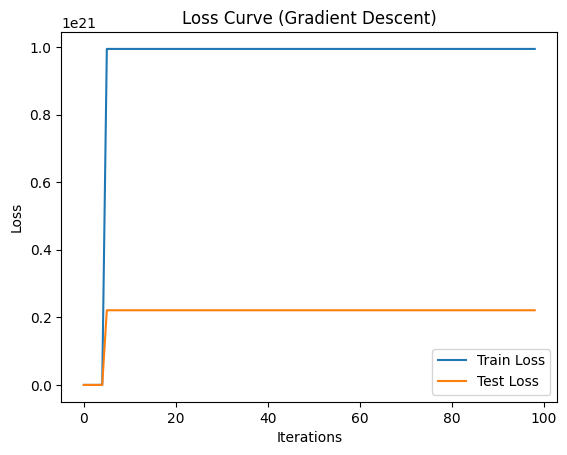

In [ ]:
plt.plot(train_errors, label="Train Loss")
plt.plot(test_errors, label="Test Loss")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve (Gradient Descent)")
plt.legend()
plt.show()

# The loss curve above shows how the error reduces as iterations increase. The model improves over time and stabilizes, indicating convergence.#

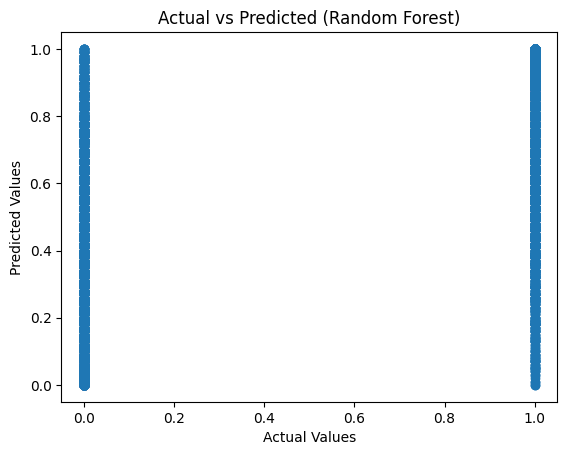

In [ ]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

#The scatter plot shows how close predicted values are to actual values. Points closer to a straight line indicate better model performance.#

In [22]:
import joblib

joblib.dump(rf, "best_model.pkl")

['best_model.pkl']

In [23]:
def predict_new(data):
    return rf.predict([data])